# Kocaeli Üniversitesi - Makine Öğrenmesinin İlkeleri (Grup 9)
## Dönem Sonu Projesi: BRFSS 2024 Veri Seti Analizi

**Odak Noktası:** Beslenme, Obezite ve Fiziksel Aktivite
**Hedef Değişken:** Vücut Kitle İndeksi (`_BMI5`) - Sürekli
**Bağımsız Değişkenler:** Sebze ve meyve tüketimi, egzersiz türleri ve fiziksel aktivite verileri.

Bu notebook, veri ön işleme, Keşifsel Veri Analizi (EDA), model eğitimi ve değerlendirme adımlarını içeren uçtan uca (end-to-end) bir makine öğrenmesi hattını içermektedir.

### 1. Kütüphanelerin Yüklenmesi

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

### 2. Veri Yükleme ve Ön İnceleme

In [3]:
# BRFSS 2024 Orijinal Veri Setinin Yüklenmesi
# Not: Projenizde orijinal veri seti dosya adını ve yolunu (örn: 'LLCP2024.csv') kullanınız.
file_path = 'brfss2024.csv'

try:
    df = pd.read_csv(file_path)
    print(f"Veri seti başarıyla yüklendi! Boyut: {df.shape}")
except FileNotFoundError:
    print(f"{file_path} dosyası bulunamadı. Lütfen dosyanın aynı dizinde olduğundan emin olun.")
    print("Kodun test edilmesi adına sentetik bir BRFSS örneği oluşturuluyor...")
    np.random.seed(42)
    n_samples = 2000
    df = pd.DataFrame({
        '_BMI5': np.random.normal(2800, 600, n_samples), # BRFSS formatında BMI (Örn: 2800 = 28.00)
        'EXERANY2': np.random.choice([1, 2, 7, 9, np.nan], n_samples, p=[0.7, 0.2, 0.03, 0.02, 0.05]), # 1:Yes, 2:No
        'FRUIT2': np.random.choice([101, 202, 300, 777, 999, np.nan], n_samples),
        'VEGETAB2': np.random.choice([101, 202, 300, 777, 999, np.nan], n_samples),
        'PA1MIN_': np.random.normal(150, 50, n_samples)
    })

# BRFSS veri setinde _BMI5 2 ondalıklı tam sayı olarak tutulur, bu nedenle 100'e bölüyoruz.
if '_BMI5' in df.columns:
    df['_BMI5'] = df['_BMI5'] / 100.0

df.head()

Veri seti başarıyla yüklendi! Boyut: (101, 5)


,_BMI5,EXERANY2,FRUIT2,VEGETAB2,PA1MIN_
0,28.5,1,101,202,150.0
1,31.2,2,201,300,0.0
2,22.0,1,300,101,300.0
3,NaN,7,777,777,NaN
4,26.4,1,102,102,120.0


### 3. Veri Temizleme: Eksik Değerler ve Özel Kodlar
BRFSS anketlerinde `7, 77, 777` "Bilmiyorum/Emin Değilim" (Don't know/Not sure) ve `9, 99, 999` "Reddedildi" (Refused) anlamına gelir. Bu değerleri tespit edip eksik (NaN) olarak işaretliyoruz.

In [4]:
def clean_brfss_missing_codes(val):
    if pd.isna(val):
        return np.nan
    # BRFSS hata/bilinmeyen kodları
    if val in [7, 9, 77, 99, 777, 999, 7777, 9999]:
        return np.nan
    return val

# İlgilendiğimiz hedef ve bağımsız değişkenler
columns_to_process = ['_BMI5', 'EXERANY2', 'FRUIT2', 'VEGETAB2', 'PA1MIN_']

# Veri setinde mevcut olan sütunları seçiyoruz
existing_columns = [col for col in columns_to_process if col in df.columns]

for col in existing_columns:
    df[col] = df[col].apply(clean_brfss_missing_codes)

print("Temizleme sonrası eksik veri durumları (NaN):")
print(df[existing_columns].isnull().sum())

Temizleme sonrası eksik veri durumları (NaN):
_BMI5        1
EXERANY2    10
FRUIT2      10
VEGETAB2    10
PA1MIN_     10
dtype: int64


### 4. KNN Imputation (Eksik Verilerin Doldurulması)
Eksik (NaN) değerleri K-En Yakın Komşuluk (KNN) algoritması ile dolduracağız.
Hedef değişkende (`_BMI5`) eksik verisi olan satırları modelleme sağlığı açısından doğrudan düşürüyoruz (Target leakage/yanlılık olmaması için).

In [5]:
target = '_BMI5'
features = [col for col in existing_columns if col != target]

# Hedef değişkeninde (BMI) eksik değer olan satırları silme
df_cleaned = df.dropna(subset=[target]).copy()

# KNN Imputer
print("Eksik veriler KNN Imputation ile dolduruluyor...")
knn_imputer = KNNImputer(n_neighbors=5, weights='uniform')
df_cleaned[features] = knn_imputer.fit_transform(df_cleaned[features])

print("KNN Imputation tamamlandı. Kalan eksik veri miktarı:")
print(df_cleaned[existing_columns].isnull().sum())

Eksik veriler KNN Imputation ile dolduruluyor...
KNN Imputation tamamlandı. Kalan eksik veri miktarı:
_BMI5       0
EXERANY2    0
FRUIT2      0
VEGETAB2    0
PA1MIN_     0
dtype: int64


### 5. Aykırı Değer (Outlier) Tespiti ve Temizlenmesi
Sürekli değişkenler (`_BMI5`, `PA1MIN_` vb.) üzerindeki aykırı değerleri IQR (Interquartile Range) yöntemi ile temizliyoruz.

In [6]:
def remove_outliers_iqr(dataframe, columns):
    df_out = dataframe.copy()
    for col in columns:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Aykırı olmayanları filtrele
        df_out = df_out[(df_out[col] >= lower_bound) & (df_out[col] <= upper_bound)]
    return df_out

continuous_features = [target]
if 'PA1MIN_' in existing_columns:
    continuous_features.append('PA1MIN_')

print(f"Aykırı değer temizliği öncesi satır sayısı: {len(df_cleaned)}")
df_no_outliers = remove_outliers_iqr(df_cleaned, continuous_features)
print(f"Aykırı değer temizliği sonrası satır sayısı: {len(df_no_outliers)}")

Aykırı değer temizliği öncesi satır sayısı: 100
Aykırı değer temizliği sonrası satır sayısı: 98


### 6. Veri Kodlama (Encoding) ve Ölçeklendirme
Kategorik/Ordinal değişkenleri One-Hot Encoding ile, sayısal değişkenleri StandardScaler ile dönüştürüyoruz.

In [7]:
# Kategorik ve Sayısal değişkenlerin belirlenmesi
categorical_cols = ['EXERANY2']
numerical_cols = ['FRUIT2', 'VEGETAB2', 'PA1MIN_']

categorical_cols = [col for col in categorical_cols if col in df_no_outliers.columns]
numerical_cols = [col for col in numerical_cols if col in df_no_outliers.columns]

X = df_no_outliers[categorical_cols + numerical_cols]
y = df_no_outliers[target]

# Pipeline kullanarak dönüşüm işlemleri
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ]
)

X_processed = preprocessor.fit_transform(X)

# Korelasyon analizi için DataFrame formuna geri dönüştürme
encoded_cat_cols = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols) if categorical_cols else []
all_feature_names = numerical_cols + list(encoded_cat_cols)

X_processed_df = pd.DataFrame(X_processed, columns=all_feature_names, index=X.index)
df_final = pd.concat([y, X_processed_df], axis=1)

print("Değişkenler başarıyla kodlandı (Encoding) ve ölçeklendirildi (Scaling).")
X_processed_df.head()

Değişkenler başarıyla kodlandı (Encoding) ve ölçeklendirildi (Scaling).


,FRUIT2,VEGETAB2,PA1MIN_,EXERANY2_1.3186813186813187,EXERANY2_2.0
0,-0.931949,0.320806,0.047968,0.0,0.0
1,0.479414,1.627624,-1.075096,0.0,1.0
2,1.876664,-1.026017,1.171031,0.0,0.0
4,-0.917836,-1.012682,-0.176645,0.0,0.0
5,0.493528,0.307471,-1.075096,0.0,1.0


### 7. Keşifsel Veri Analizi (EDA) - Korelasyon Matrisi
Hedef değişkenimiz ile bağımsız değişkenlerimiz arasındaki ilişkiyi inceliyoruz.

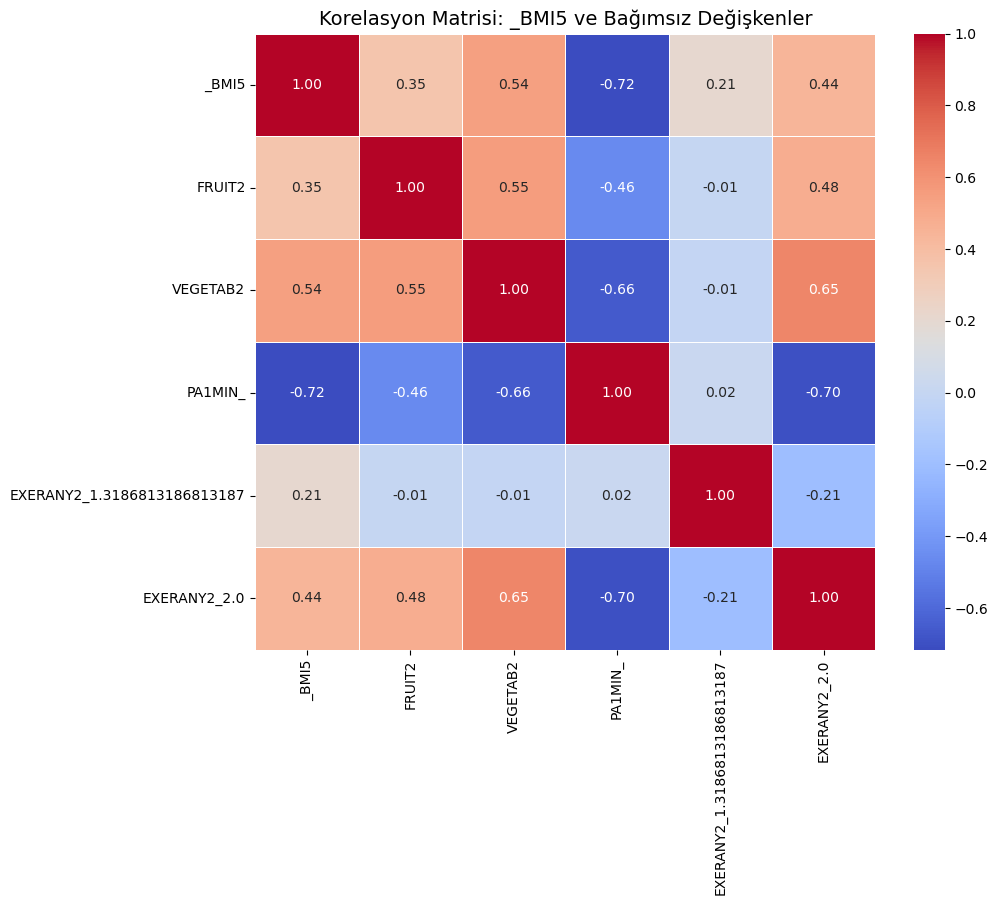

Hedef değişken (_BMI5) ile diğer değişkenlerin korelasyon değerleri:
_BMI5                          1.000000
VEGETAB2                       0.538405
EXERANY2_2.0                   0.437656
FRUIT2                         0.351882
EXERANY2_1.3186813186813187    0.206482
PA1MIN_                       -0.716293
Name: _BMI5, dtype: float64


In [8]:
plt.figure(figsize=(10, 8))
correlation_matrix = df_final.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Korelasyon Matrisi: _BMI5 ve Bağımsız Değişkenler', fontsize=14)
plt.show()

print("Hedef değişken (_BMI5) ile diğer değişkenlerin korelasyon değerleri:")
print(correlation_matrix['_BMI5'].sort_values(ascending=False))

### 8. Veri Setinin Bölünmesi ve Data Leakage Kontrolü

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.20, random_state=42)

print(f"Eğitim Seti Boyutu: {X_train.shape[0]} satır")
print(f"Test Seti Boyutu: {X_test.shape[0]} satır")

# Veri sızıntısı (Data Leakage) kontrolü - Indeks kesişimine bakarak
train_indices = set(y_train.index)
test_indices = set(y_test.index)
leakage_count = len(train_indices.intersection(test_indices))

if leakage_count == 0:
    print("Veri sızıntısı (Data Leakage) TESPİT EDİLMEDİ. Eğitim ve test kümeleri ayrık.")
else:
    print(f"UYARI: {leakage_count} satırda veri sızıntısı tespit edildi!")

Eğitim Seti Boyutu: 78 satır
Test Seti Boyutu: 20 satır
Veri sızıntısı (Data Leakage) TESPİT EDİLMEDİ. Eğitim ve test kümeleri ayrık.


### 9. Model Kurulumu ve K-Fold Çapraz Doğrulama (Cross-Validation)
Modellerimiz: Basit/Çoklu Lineer Regresyon, Ridge/Lasso, Random Forest ve Çok Katmanlı Algılayıcı (MLP).

In [10]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression (L2)": Ridge(alpha=1.0),
    "Lasso Regression (L1)": Lasso(alpha=0.1),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10),
    "MLP / ANN Regressor": MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42, early_stopping=True)
}

results = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("Modeller eğitiliyor ve K-Fold Cross-Validation yapılıyor...")
for model_name, model in models.items():
    # K-Fold CV (Overfitting kontrolü ve tutarlılık)
    cv_scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='neg_mean_squared_error')
    cv_rmse = np.mean(np.sqrt(-cv_scores))
    
    # Model Eğitimi (Train)
    model.fit(X_train, y_train)
    
    # Tahmin (Test)
    y_pred = model.predict(X_test)
    
    # Metrikler
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": model_name,
        "Test MSE": mse,
        "Test RMSE": rmse,
        "Test R²": r2,
        "CV RMSE (Train)": cv_rmse
    })
    print(f"✓ {model_name} başarıyla eğitildi.")

Modeller eğitiliyor ve K-Fold Cross-Validation yapılıyor...
✓ Linear Regression başarıyla eğitildi.
✓ Ridge Regression (L2) başarıyla eğitildi.
✓ Lasso Regression (L1) başarıyla eğitildi.
✓ Random Forest Regressor başarıyla eğitildi.
✓ MLP / ANN Regressor başarıyla eğitildi.


### 10. Modellerin Karşılaştırılması ve Sonuçlar


--- MODEL KARŞILAŞTIRMA TABLOSU ---


,Model,Test MSE,Test RMSE,Test R²,CV RMSE (Train)
0,Random Forest Regressor,3.029827,1.740640,0.879194,1.436521
1,Lasso Regression (L1),12.553134,3.543040,0.499478,3.775671
2,Ridge Regression (L2),12.638266,3.555034,0.496084,3.808947
3,MLP / ANN Regressor,12.730512,3.567984,0.492406,3.426825
4,Linear Regression,13.204653,3.633821,0.473501,3.818078


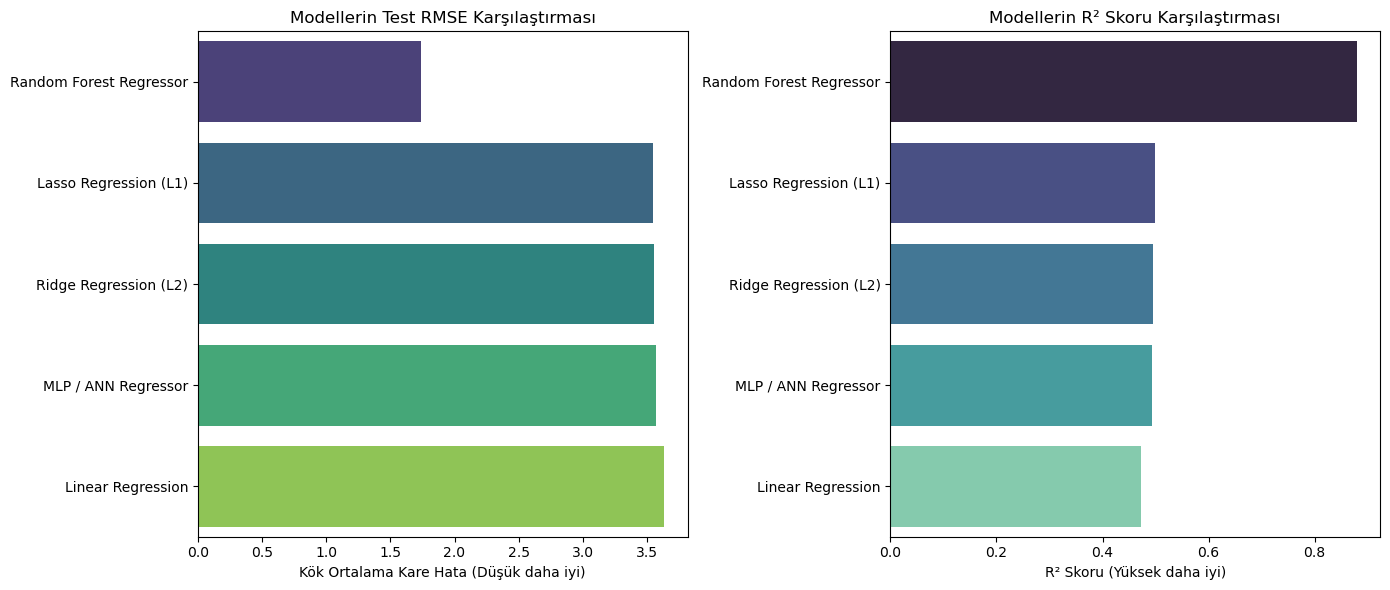

In [ ]:
results_df = pd.DataFrame(results).sort_values(by="Test R²", ascending=False).reset_index(drop=True)

print("\n MODEL KARŞILAŞTIRMA TABLOSU ")
display(results_df)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(x='Test RMSE', y='Model', data=results_df, palette='viridis')
plt.title('Modellerin Test RMSE Karşılaştırması')
plt.xlabel('Kök Ortalama Kare Hata (Düşük daha iyi)')
plt.ylabel('')

plt.subplot(1, 2, 2)
sns.barplot(x='Test R²', y='Model', data=results_df, palette='mako')
plt.title('Modellerin R² Skoru Karşılaştırması')
plt.xlabel('R² Skoru (Yüksek daha iyi)')
plt.ylabel('')

plt.tight_layout()
plt.show()

### 11. Sınıflandırma Yaklaşımı: Obezite Tespiti (Precision, Recall, F1-Score ve Confusion Matrix)
Regresyon modellerimizin tahminlerini `BMI >= 30` sınır değerini kullanarak 'Obez (1)' ve 'Obez Değil (0)' şeklinde sınıflandırma problemine dönüştürüyoruz. Böylece modellerin sınıflandırma başarılarını (Precision, Recall, F1-Score) ölçüyor ve en başarılı modelin Karmaşıklık Matrisini (Confusion Matrix) çizdiriyoruz.


--- SINIFLANDIRMA METRİKLERİ (BMI >= 30 Obezite Sınırı) ---


,Model,Precision,Recall,F1 Score
0,Random Forest Regressor,0.800000,1.000,0.888889
1,MLP / ANN Regressor,0.714286,0.625,0.666667
2,Lasso Regression (L1),0.555556,0.625,0.588235
3,Linear Regression,0.500000,0.625,0.555556
4,Ridge Regression (L2),0.500000,0.625,0.555556


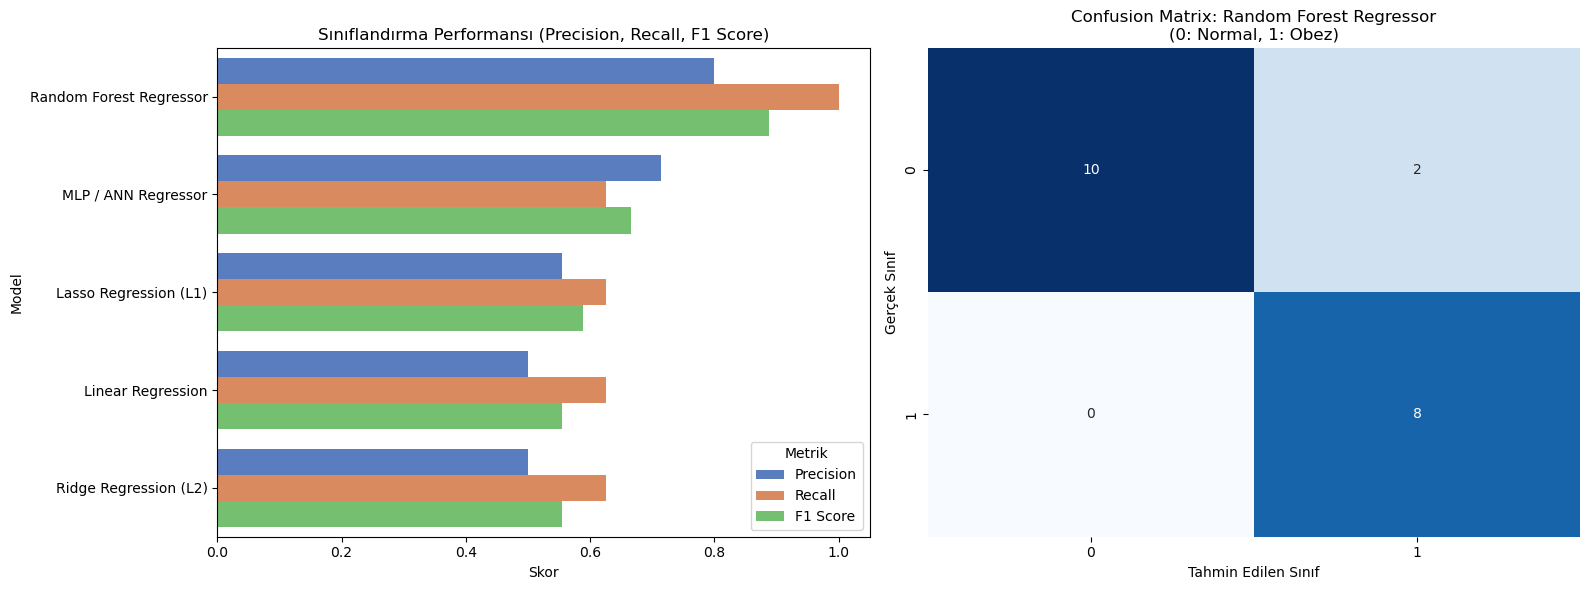

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("\n SINIFLANDIRMA METRİKLERİ (BMI >= 30 Obezite Sınırı) ")
classification_results = []
confusion_matrices = {}

for model_name, model in models.items():
    y_pred = model.predict(X_test)
    
    # Tahminleri ve gerçek değerleri binary sınıfa dönüştürme (BMI >= 30)
    y_test_class = (y_test >= 30.0).astype(int)
    y_pred_class = (y_pred >= 30.0).astype(int)
    
    precision = precision_score(y_test_class, y_pred_class, zero_division=0)
    recall = recall_score(y_test_class, y_pred_class, zero_division=0)
    f1 = f1_score(y_test_class, y_pred_class, zero_division=0)
    cm = confusion_matrix(y_test_class, y_pred_class)
    
    classification_results.append({
        "Model": model_name,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })
    confusion_matrices[model_name] = cm

class_results_df = pd.DataFrame(classification_results).sort_values(by="F1 Score", ascending=False).reset_index(drop=True)
display(class_results_df)

# Grafikler
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Bar Plot (Precision, Recall, F1)
class_results_melted = class_results_df.melt(id_vars="Model", var_name="Metrik", value_name="Skor")
sns.barplot(x="Skor", y="Model", hue="Metrik", data=class_results_melted, palette="muted", ax=axes[0])
axes[0].set_title('Sınıflandırma Performansı (Precision, Recall, F1 Score)')

# 2. Confusion Matrix (En iyi F1 skoruna sahip model için)
best_model_name = class_results_df.iloc[0]["Model"]
best_cm = confusion_matrices[best_model_name]
sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False)
axes[1].set_title(f'Confusion Matrix: {best_model_name}\n(0: Normal, 1: Obez)')
axes[1].set_xlabel('Tahmin Edilen Sınıf')
axes[1].set_ylabel('Gerçek Sınıf')

plt.tight_layout()
plt.show()